# Clase 10 — Analizando el catálogo de Netflix

En este ejercicio asumirás el rol de un **Data Analyst** dentro de Netflix. El equipo de negocio quiere entender mejor cómo está distribuido el catálogo de la plataforma para tomar decisiones sobre futuras inversiones en contenido.

Para ello deberás utilizar las herramientas aprendidas en esta clase:

- `groupby()`
- funciones de agregación
- `agg()`
- `pivot_table()`
- `unstack()`
- gráficos con Pandas y Matplotlib

> No utilices bucles (`for`) para resolver los ejercicios.


## Parte 1: Exploración del dataset

Antes de comenzar el análisis responde:

1. Carga el dataset.
2. Muestra las primeras filas.
3. ¿Cuántas filas y columnas posee?
4. ¿Qué tipo de dato tiene cada columna?
5. ¿Existen valores nulos?
6. ¿Qué columnas presentan mayor cantidad de valores faltantes?

In [5]:
import pandas as pd

# Carga directa del dataset de Netflix desde GitHub
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv'
df = pd.read_csv(url)








In [6]:
# tú código acá
import pandas as pd

# 1. Cargar el dataset directamente desde la web
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv'
df = pd.read_csv(url)

# 2. Mostrar las primeras 5 filas
df.head()

# # 2. Mostrar las primeras 5 filas
print("--- Primeras filas del catálogo ---")
print(df.head())

# # 3. Cantidad de filas y columnas (Shape)
filas, columnas = df.shape
print(f"\n3. El dataset posee {filas} filas y {columnas} columnas.")

# # 4. Tipo de dato de cada columna
print("\n4. Tipos de datos por columna:")
print(df.dtypes)

# # 5. Conteo general de valores nulos por columna
print("\n5. Conteo de valores nulos por columna:")
nulos = df.isnull().sum()
print(nulos)

# 6. Columnas con mayor cantidad de valores faltantes (ordenadas de mayor a menor)
print("\n6. Top de columnas con más valores faltantes:")
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Porcentaje (%)': nulos_porcentaje.round(2)
}).sort_values(by='Valores Nulos', ascending=False)

print(df_nulos[df_nulos['Valores Nulos'] > 0])

--- Primeras filas del catálogo ---
  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

          date_added  release_year rating   duration  \
0    August 14, 2020          2020  TV-MA  4 Seasons   
1  December 23, 2016          2016  TV-MA     93 min   
2  December 20, 2018          2011      R     78 min   
3  November 16, 2017    

## Parte 2: Agrupaciones

### Ejercicio 1 - ¿Cuántos títulos existen por país?

Ordena el resultado de mayor a menor.


In [27]:
# tu código acá
import pandas as pd


# Contar títulos por país y ordenar de mayor a menor
titulos_por_pais = (
    df.groupby('country')['show_id']
    .count()
    .sort_values(ascending=False)
)
print("\n7. Cantidad de títulos por país (ordenados de mayor a menor):")
print(titulos_por_pais)


7. Cantidad de títulos por país (ordenados de mayor a menor):
country
United States                            2555
India                                     923
United Kingdom                            397
Japan                                     226
South Korea                               183
                                         ... 
Australia, New Zealand, United States       1
Australia, United Kingdom                   1
Australia, United Kingdom, Canada           1
Argentina, United States, Mexico            1
Argentina, United States                    1
Name: show_id, Length: 681, dtype: int64


### Ejercicio 2 - ¿Cuántas películas y cuántas series tiene Netflix?

In [7]:
# tu código acá

# Contamos cuántos títulos hay por cada tipo
df.groupby('type')['show_id'].count()
print("\n8. Cantidad de títulos por tipo (Movie/TV Show):")
print(df.groupby('type')['show_id'].count())


8. Cantidad de títulos por tipo (Movie/TV Show):
type
Movie      5377
TV Show    2410
Name: show_id, dtype: int64


### Ejercicio 3 - ¿Cuántos títulos fueron lanzados cada año?

Ordena el resultado cronológicamente.


In [9]:
# tu código acá
titulos_por_año = df.groupby('release_year')['show_id'].count().sort_index()
print("\n9. Cantidad de títulos por año de lanzamiento:")

df['release_year'].value_counts()


9. Cantidad de títulos por año de lanzamiento:


release_year
2018    1121
2017    1012
2019     996
2016     882
2020     868
        ... 
1966       1
1925       1
1964       1
1947       1
1959       1
Name: count, Length: 73, dtype: int64

### Ejercicio 4 - ¿Cuál es la clasificación por edades más frecuente?

Por ejemplo:

- TV-MA
- TV-14
- PG
- R

In [11]:
# tu código acá
df.groupby('rating')['show_id'].count().sort_values(ascending=False)
print("\n10. Cantidad de títulos por clasificación (rating):")
df['rating'].value_counts()


10. Cantidad de títulos por clasificación (rating):


rating
TV-MA       2863
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

### Ejercicio 5 - Obtén para cada tipo de contenido (Movie y TV Show):

- cantidad de títulos
- año promedio de lanzamiento
- año más reciente
- año más antiguo

> Utiliza **agg()**.

In [16]:
# tu código acá
resumen_por_tipo = df.groupby('type')['release_year'].agg(
    cantidad_titulos="count",
    anio_promedio="mean",
    anio_mas_reciente="max",
    anio_mas_antiguo="min"
)   

print("\n11. Resumen por tipo de contenido (Movie/TV Show):")
print(resumen_por_tipo)


11. Resumen por tipo de contenido (Movie/TV Show):
         cantidad_titulos  anio_promedio  anio_mas_reciente  anio_mas_antiguo
type                                                                         
Movie                5377    2012.920030               2021              1942
TV Show              2410    2016.191701               2021              1925


## Parte 3: Agrupaciones múltiples

### Ejercicio 6 - Obtén la cantidad de títulos para cada combinación.

Agrupa por:

- país
- tipo de contenido

In [18]:
# tu código acá
df.groupby(["country", "type"])["show_id"].count()



country                                              type   
Argentina                                            Movie      34
                                                     TV Show    16
Argentina, Brazil, France, Poland, Germany, Denmark  Movie       1
Argentina, Chile                                     Movie       1
Argentina, Chile, Peru                               Movie       1
                                                                ..
Venezuela                                            Movie       1
Venezuela, Colombia                                  Movie       1
Vietnam                                              Movie       5
West Germany                                         Movie       1
Zimbabwe                                             Movie       1
Name: show_id, Length: 773, dtype: int64

### Ejercicio 7 - Convierte el resultado anterior en una tabla donde:

- las filas sean los países
- las columnas sean Movie y TV Show

> Utiliza **unstack()**.

In [19]:
# tu código acá
tabla_paises = df.groupby(["country", "type"])["show_id"].count().unstack() 

tabla_paises.head(10)

type,Movie,TV Show
country,,
Argentina,34.0,16.0
"Argentina, Brazil, France, Poland, Germany, Denmark",1.0,NaN
"Argentina, Chile",1.0,NaN
"Argentina, Chile, Peru",1.0,NaN
"Argentina, France",1.0,NaN
"Argentina, France, United States, Germany, Qatar",1.0,NaN
"Argentina, Italy",1.0,NaN
"Argentina, Spain",7.0,1.0
"Argentina, United States",1.0,NaN


## Parte 4: Tablas dinámicas

### Ejercicio 8 - Construye una tabla dinámica donde:

- filas → país
- columnas → tipo de contenido
- valores → cantidad de títulos

In [22]:
# tu código acá
tabla_dinamica = df.pivot_table(
    index='country',
    columns='type',
    values='show_id',
    aggfunc='count',
    fill_value=0    
)
tabla_dinamica.head(10)

type,Movie,TV Show
country,,
Argentina,34,16
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",1,0
"Argentina, Chile, Peru",1,0
"Argentina, France",1,0
"Argentina, France, United States, Germany, Qatar",1,0
"Argentina, Italy",1,0
"Argentina, Spain",7,1
"Argentina, United States",1,0


### Ejercicio 9 - Construye otra tabla dinámica donde:

- filas → clasificación por edades
- columnas → tipo de contenido
- valores → cantidad de títulos

In [23]:
# tu código acá
tabla_rating= df.pivot_table(
    index='country',
    columns='type',
    values='show_id',
    aggfunc='count',
    fill_value=0
)  

tabla_rating


type,Movie,TV Show
country,,
Argentina,34,16
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",1,0
"Argentina, Chile, Peru",1,0
"Argentina, France",1,0
...,...,...
Venezuela,1,0
"Venezuela, Colombia",1,0
Vietnam,5,0


### Ejercicio 10 - Modifica la tabla dinámica para que los valores faltantes aparezcan como **0**.

In [24]:
# tu código acá
tabla_dinamica = df.pivot_table(index='country', columns='type', values='show_id', aggfunc='count', fill_value=0)

tabla_dinamica

type,Movie,TV Show
country,,
Argentina,34,16
"Argentina, Brazil, France, Poland, Germany, Denmark",1,0
"Argentina, Chile",1,0
"Argentina, Chile, Peru",1,0
"Argentina, France",1,0
...,...,...
Venezuela,1,0
"Venezuela, Colombia",1,0
Vietnam,5,0


## Parte 5: Visualización

### Ejercicio 11 - Genera un gráfico de barras con el **Top 10 países con mayor cantidad de títulos**.

El gráfico debe incluir:

- título
- tamaño de figura
- etiquetas rotadas
- eje Y con nombre


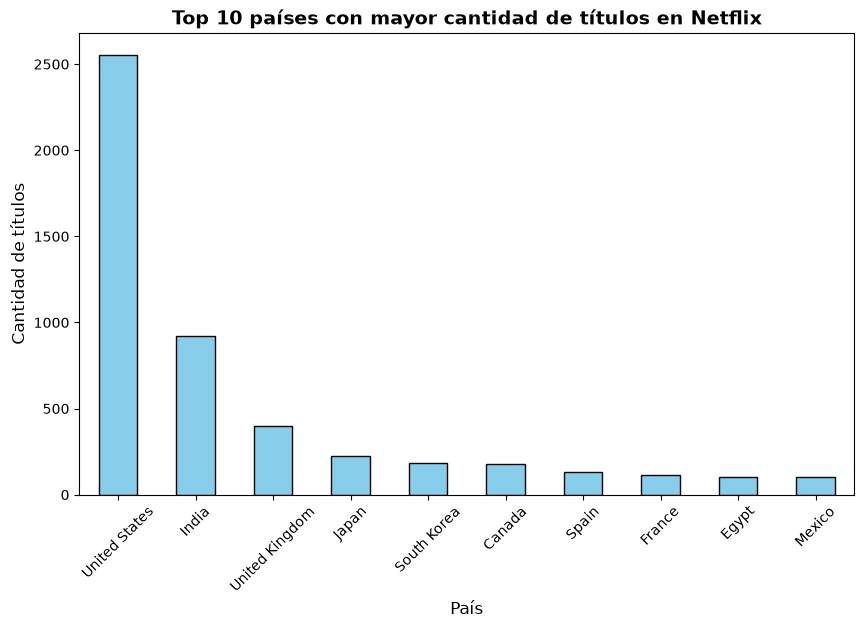

In [25]:
# tu código acá
import matplotlib.pyplot as plt

top_10_paises = df['country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_10_paises.plot(kind='bar', color='skyblue',edgecolor='black')
plt.title('Top 10 países con mayor cantidad de títulos en Netflix', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Cantidad de títulos', fontsize=12)

plt.xticks(rotation=45)

plt.show()



### Ejercicio 12 - Genera un gráfico de barras mostrando la cantidad de:

- Movies
- TV Shows

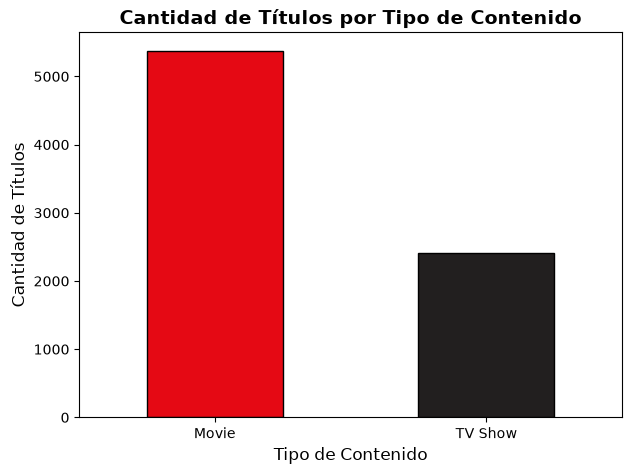

In [27]:
# tu código acá
import matplotlib.pyplot as plt

# 1. Contamos la cantidad de Películas y Series
conteo_tipo = df['type'].value_counts()

# 2. Definimos el tamaño de la figura (ancho, alto)
plt.figure(figsize=(7, 5))

# 3. Creamos el gráfico de barras asignando colores distintos
conteo_tipo.plot(kind='bar', color=['#E50914', '#221F1F'], edgecolor='black')

# 4. Agregamos título y etiquetas a los ejes
plt.title('Cantidad de Títulos por Tipo de Contenido', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contenido', fontsize=12)
plt.ylabel('Cantidad de Títulos', fontsize=12)

# 5. Mantenemos las etiquetas del eje X horizontales (no hace falta rotar porque son solo 2)
plt.xticks(rotation=0)

# 6. Mostramos el gráfico
plt.show()

### Ejercicio 13 - Utilizando la tabla dinámica, crea un gráfico de barras agrupadas que compare películas y series por país.


In [ ]:
# tu código acá

## Parte 6: Análisis

Redacta al menos **cinco insights** basados en el análisis realizado. Algunas preguntas que puedes responder son:

- ¿Qué país domina el catálogo?
- ¿Netflix posee más películas o más series?
- ¿Qué clasificación por edades es la más utilizada?
- ¿Existen países donde predominen las series?
- ¿Qué tendencia observas respecto al año de lanzamiento de los contenidos?

Justifica cada respuesta utilizando los datos obtenidos.

In [ ]:
# tu código acá

## Desafío

Netflix desea aumentar su presencia en Latinoamérica. Analiza únicamente los siguientes países:

- Argentina
- Brasil
- Chile
- Colombia
- México
- Perú

Responde:

1. ¿Cuál aporta mayor cantidad de contenido?
2. ¿Predominan las películas o las series?
3. ¿Qué clasificación por edades es la más común?
4. Genera un gráfico comparativo.
5. Escribe una breve recomendación para el director regional de Netflix basada en tus resultados.


In [ ]:
# tu código acá